## Dataset Information

This dataset comprises of sales transactions captured at a retail store. It’s a classic dataset to explore and expand your feature engineering skills and day to day understanding from multiple shopping experiences. This is a regression problem. The dataset has 550,069 rows and 12 columns.

**Problem:** Predict purchase amount

## Attributes:
| Column ID |         Column Name        | Data type |           Description           | Masked |
|:---------:|:--------------------------:|:---------:|:-------------------------------:|--------|
|     0     |           User_ID          |   int64   |      Unique Id of customer      | False  |
|     1     |         Product_ID         |   object  |       Unique Id of product      | False  |
|     2     |           Gender           |   object  |         Sex of customer         | False  |
|     3     |             Age            |   object  |         Age of customer         | False  |
|     4     |         Occupation         |   int64   |   Occupation code of customer   | True   |
|     5     |        City_Category       |   object  |         City of customer        | True   |
|     6     | Stay_In_Current_City_Years |   object  | Number of years of stay in city | False  |
|     7     |       Marital_Status       |   int64   |    Marital status of customer   | False  |
|     8     |     Product_Category_1     |   int64   |       Category of product       | True   |
|     9     |     Product_Category_2     |  float64  |       Category of product       | True   |
|     10    |     Product_Category_3     |  float64  |       Category of product       | True   |
|     11    |          Purchase          |   int64   |         Purchase amount         | False  |

## Import modules

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load the dataset

In [2]:
df = pd.read_csv('train.csv')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [3]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,4.065680e+05,406568.000000,406568.000000,406568.000000,280441.000000,124440.000000,406568.000000
mean,1.002958e+06,8.079123,0.410207,5.296450,9.848649,12.654822,9326.147306
std,1.732135e+03,6.524450,0.491872,3.748147,5.089139,4.128853,4975.886287
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,185.000000
25%,1.001447e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5866.000000
50%,1.002946e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8061.000000
75%,1.004422e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12066.000000
max,1.006040e+06,20.000000,1.000000,18.000000,18.000000,18.000000,23961.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406568 entries, 0 to 406567
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     406568 non-null  int64  
 1   Product_ID                  406568 non-null  object 
 2   Gender                      406568 non-null  object 
 3   Age                         406568 non-null  object 
 4   Occupation                  406568 non-null  int64  
 5   City_Category               406568 non-null  object 
 6   Stay_In_Current_City_Years  406568 non-null  object 
 7   Marital_Status              406568 non-null  int64  
 8   Product_Category_1          406568 non-null  int64  
 9   Product_Category_2          280441 non-null  float64
 10  Product_Category_3          124440 non-null  float64
 11  Purchase                    406568 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 37.2+ MB


In [5]:
# Count unique values
df.nunique()

,0
User_ID,5891
Product_ID,3579
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category_1,18
Product_Category_2,17


## EDA

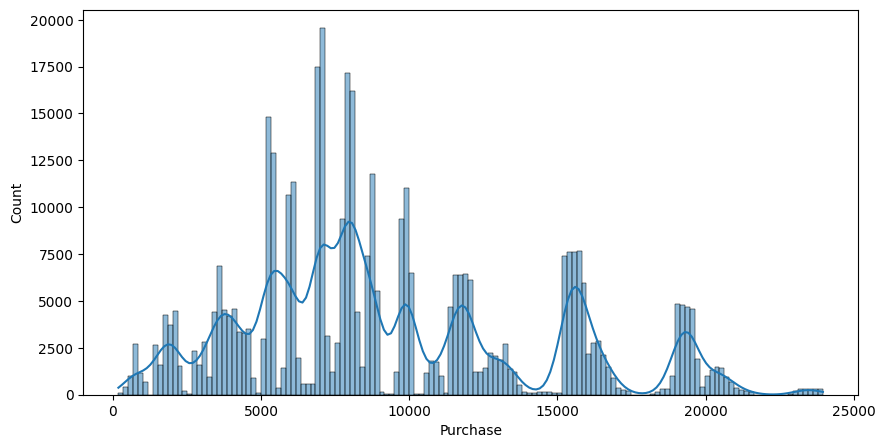

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Purchase'], kde=True)
plt.show()
# >> Note: Purchase has a wide range. We can do log transformation...

<Axes: xlabel='Gender', ylabel='count'>

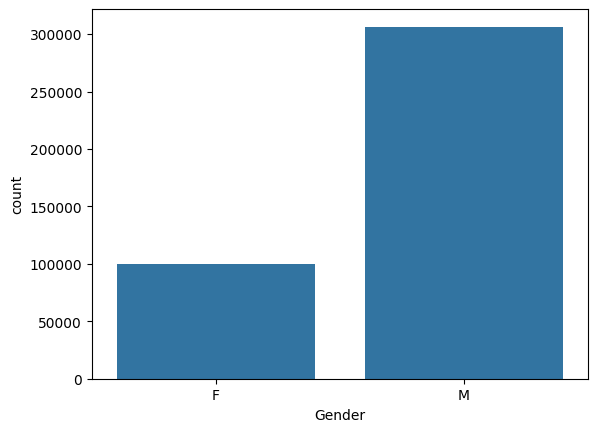

In [7]:
# Distribution of numeric variables
sns.countplot(x=df['Gender'])

<Axes: xlabel='Age', ylabel='count'>

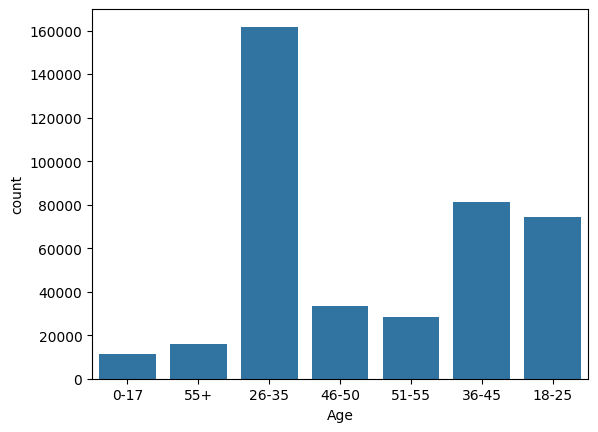

In [8]:
sns.countplot(x=df['Age'])

<Axes: xlabel='Occupation', ylabel='count'>

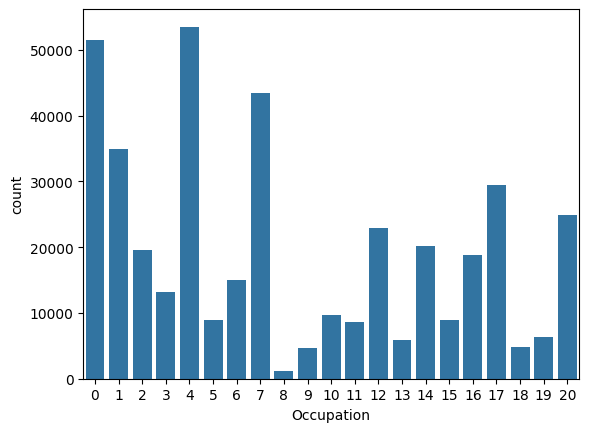

In [9]:
sns.countplot(x=df['Occupation'])

<Axes: xlabel='City_Category', ylabel='count'>

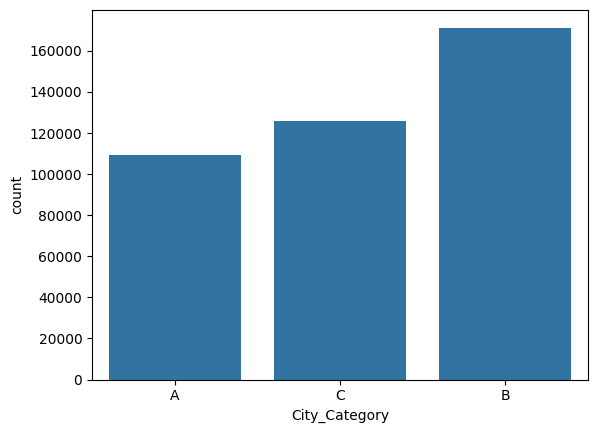

In [10]:
sns.countplot(x=df['City_Category'])

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

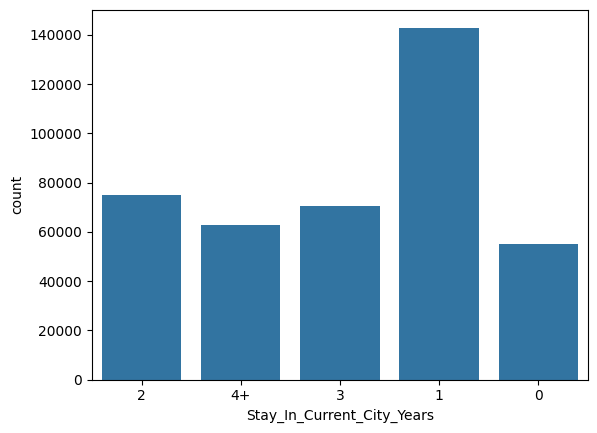

In [11]:
sns.countplot(x=df['Stay_In_Current_City_Years'])

<Axes: xlabel='Marital_Status', ylabel='count'>

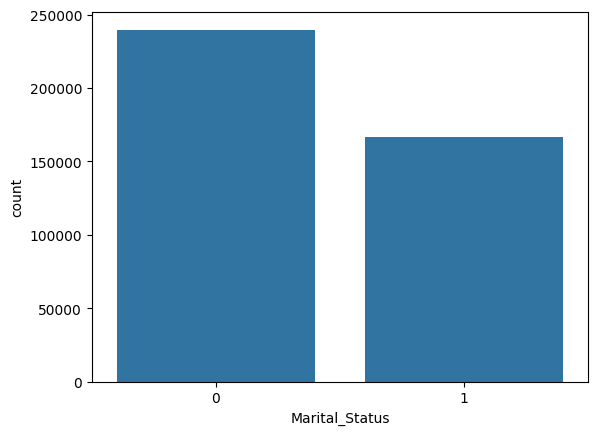

In [12]:
sns.countplot(x=df['Marital_Status'])

<Axes: xlabel='Product_Category_1', ylabel='count'>

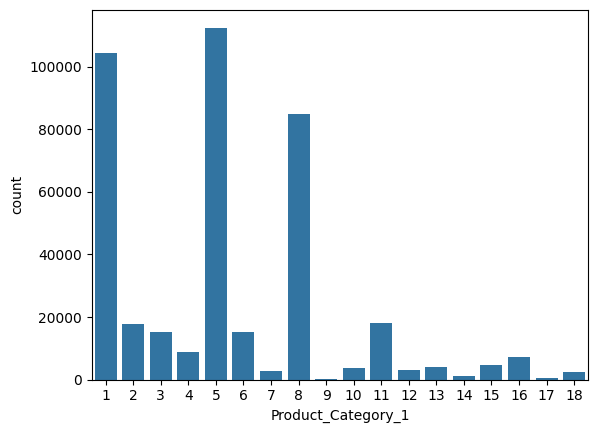

In [13]:
sns.countplot(x=df['Product_Category_1'])

<Axes: xlabel='Product_Category_2', ylabel='count'>

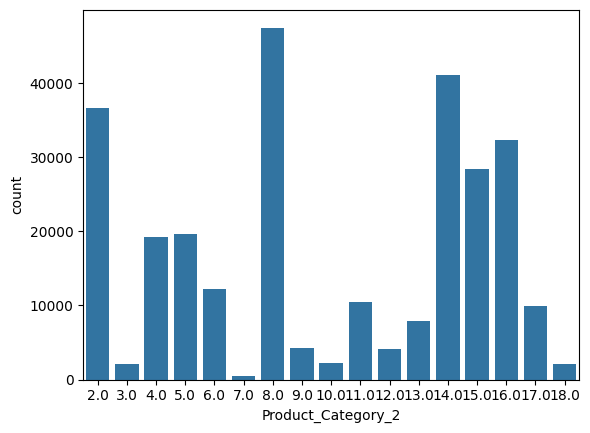

In [14]:
sns.countplot(x=df['Product_Category_2'])

<Axes: xlabel='Product_Category_3', ylabel='count'>

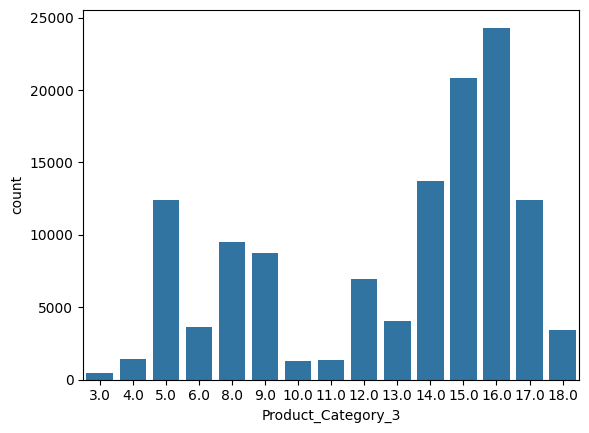

In [15]:
sns.countplot(x=df['Product_Category_3'])

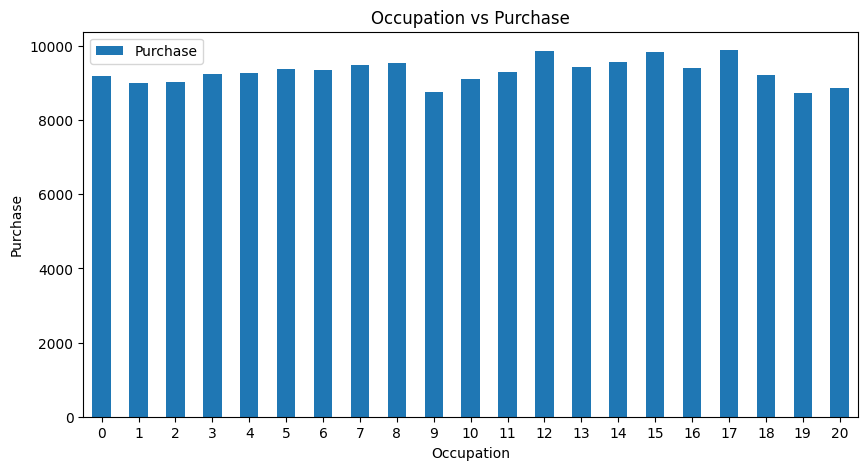

In [16]:
# Bivariate analysis
occupation_plot = df.pivot_table(index='Occupation', values='Purchase', aggfunc='mean')
occupation_plot.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Occupation')
plt.ylabel('Purchase')
plt.title('Occupation vs Purchase')
plt.xticks(rotation=0)
plt.show()

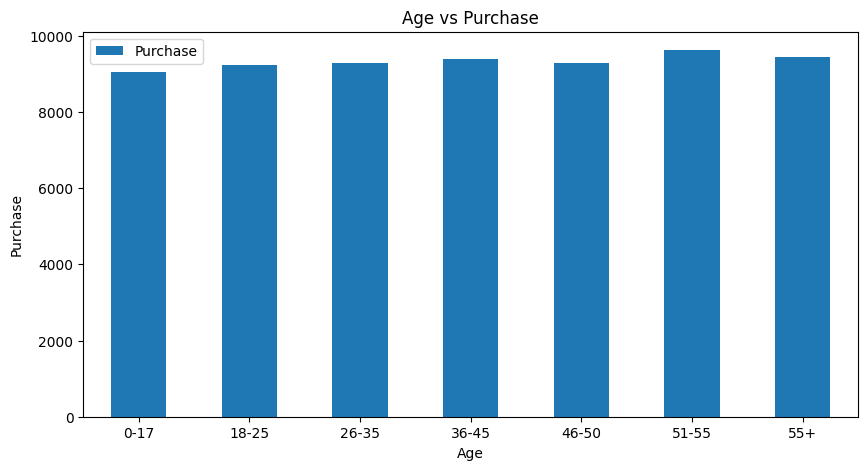

In [17]:
age_plot = df.pivot_table(index='Age', values='Purchase', aggfunc='mean')
age_plot.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Age')
plt.ylabel('Purchase')
plt.title('Age vs Purchase')
plt.xticks(rotation=0)
plt.show()

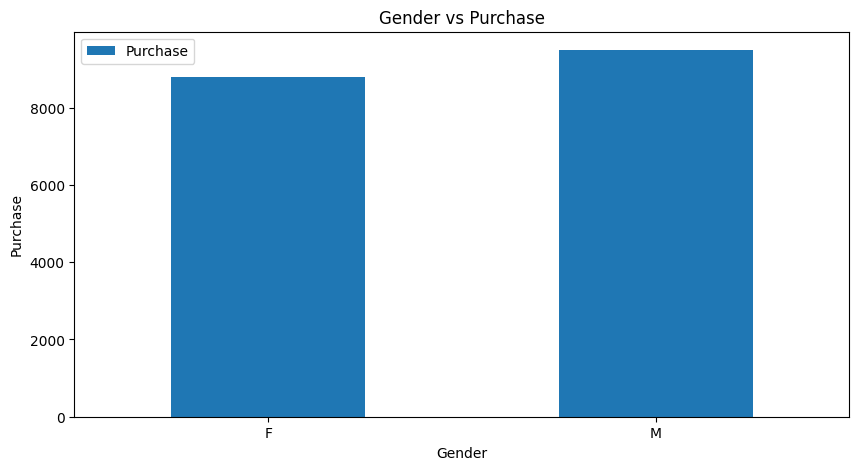

In [18]:
age_plot = df.pivot_table(index='Gender', values='Purchase', aggfunc='mean')
age_plot.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Gender')
plt.ylabel('Purchase')
plt.title('Gender vs Purchase')
plt.xticks(rotation=0)
plt.show()

## Preprocessing the dataset

In [19]:
# Check for null values
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,126127


In [20]:
df['Product_Category_2'] = df['Product_Category_2'].fillna(-2.0).astype("float32")
df['Product_Category_3'] = df['Product_Category_3'].fillna(-2.0).astype("float32")

In [21]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,0


In [22]:
# Encoding values using dict
gender_dict = {'F':0, 'M':1}
df['Gender'] = df['Gender'].apply(lambda x: gender_dict[x])
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,0,0-17,10,A,2,0,3,-2.0,-2.0,8370
1,1000001,P00248942,0,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,0,0-17,10,A,2,0,12,-2.0,-2.0,1422
3,1000001,P00085442,0,0-17,10,A,2,0,12,14.0,-2.0,1057
4,1000002,P00285442,1,55+,16,C,4+,0,8,-2.0,-2.0,7969


In [23]:
# To improve the metric use one hot encoding
# Label encoding
from sklearn.preprocessing import LabelEncoder

cols = ['Age', 'City_Category', 'Stay_In_Current_City_Years']
le = LabelEncoder()
for col in cols:
    df[col] = le.fit_transform(df[col])
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,0,0,10,0,2,0,3,-2.0,-2.0,8370
1,1000001,P00248942,0,0,10,0,2,0,1,6.0,14.0,15200
2,1000001,P00087842,0,0,10,0,2,0,12,-2.0,-2.0,1422
3,1000001,P00085442,0,0,10,0,2,0,12,14.0,-2.0,1057
4,1000002,P00285442,1,6,16,2,4,0,8,-2.0,-2.0,7969


### Correlation matrix

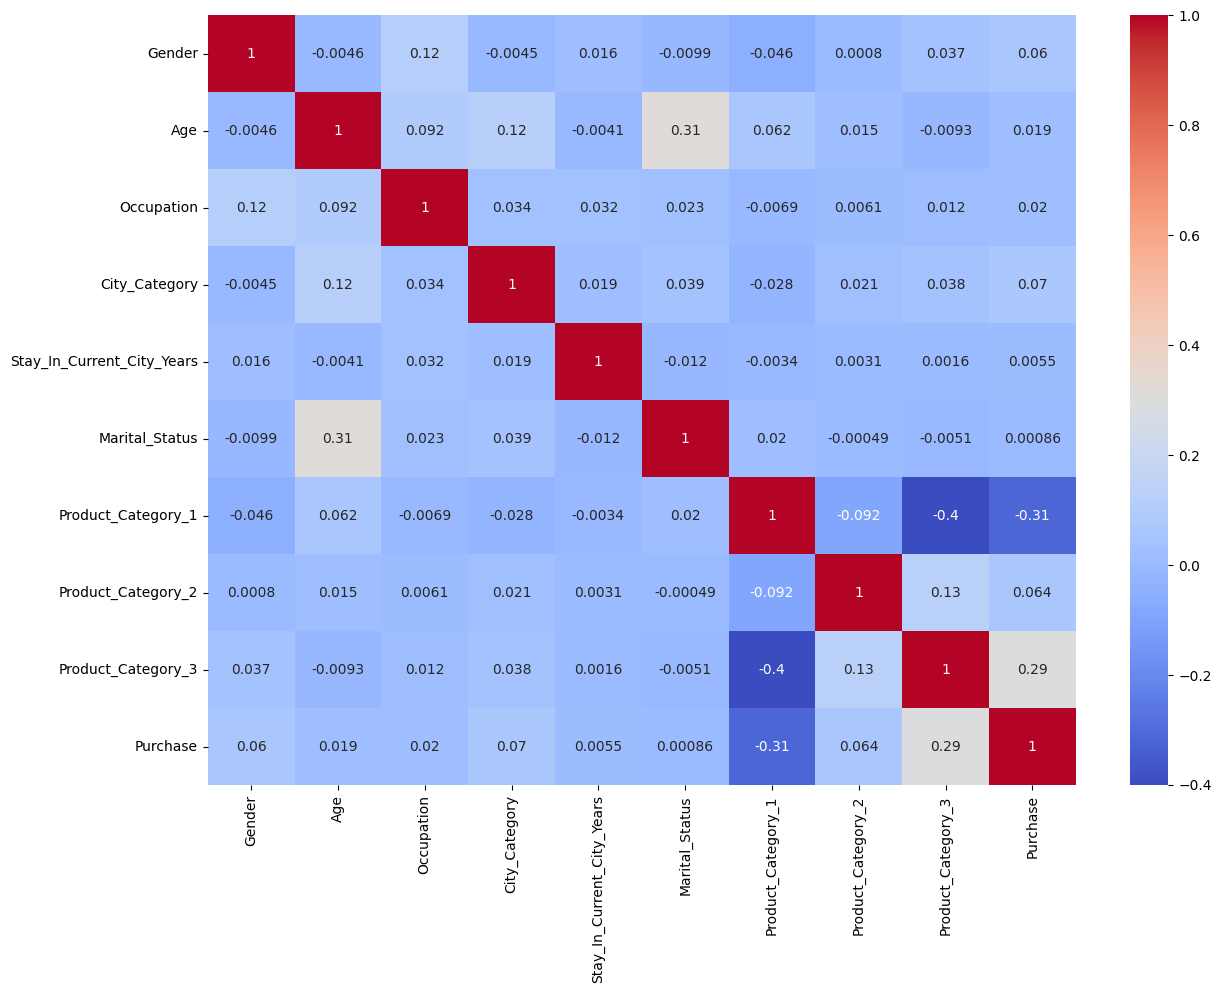

In [24]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.drop(['User_ID', 'Product_ID'], axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

## Input split

In [25]:
# Input must remove User_ID and Product_ID to avoid bias
X = df.drop(['User_ID', 'Product_ID', 'Purchase'], axis=1)
y = df['Purchase']

## Model training and evaluation

In [26]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error

def train(model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cv_score = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    cv_score = np.abs(np.mean(cv_score))
    print("Results:")
    print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
    print(f'CV Score: {np.sqrt(cv_score)}')

Results:
RMSE: 4621.542874335947
CV Score: 4623.988156844236


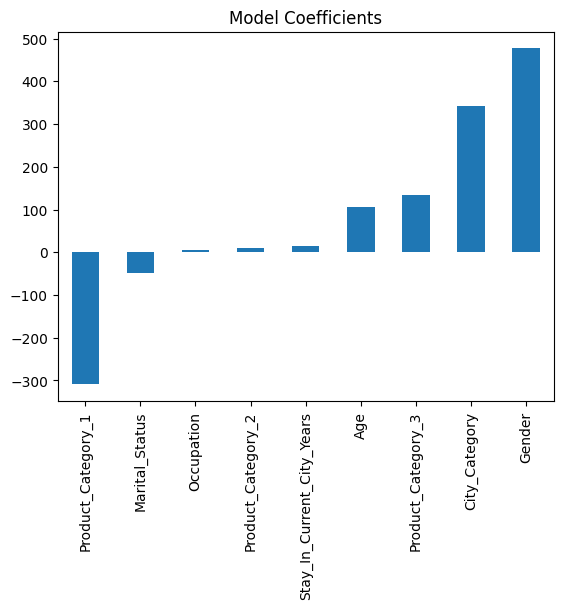

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
train(model, X, y)
coef = pd.Series(model.coef_, X.columns).sort_values()
coef.plot(kind='bar', title='Model Coefficients')
plt.show()

Results:
RMSE: 3420.038097307315
CV Score: 3421.062451354521


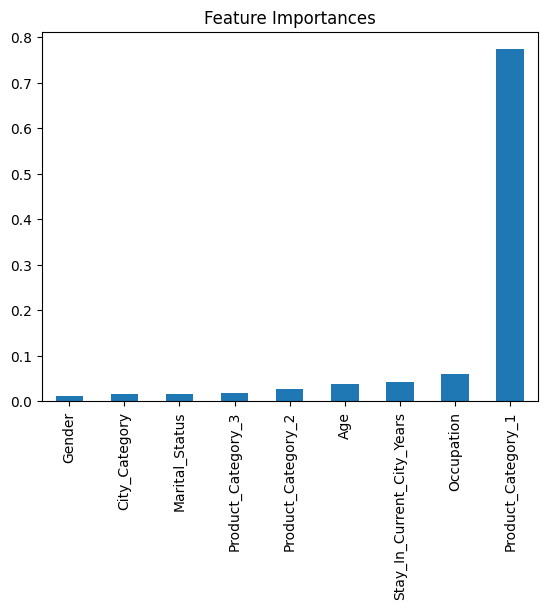

In [28]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
train(model, X, y)
feature_importances = pd.Series(model.feature_importances_, X.columns).sort_values()
feature_importances.plot(kind='bar', title='Feature Importances')
plt.show()

Results:
RMSE: 3071.049897921387
CV Score: 3077.3349202352547


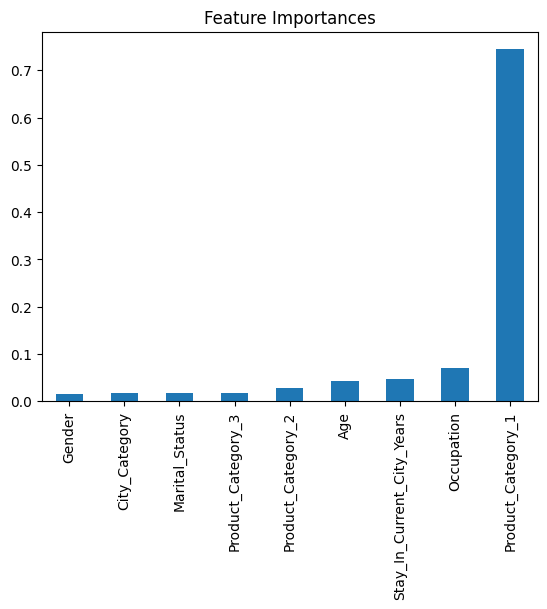

In [29]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_jobs=-1)
train(model, X, y)
feature_importances = pd.Series(model.feature_importances_, X.columns).sort_values()
feature_importances.plot(kind='bar', title='Feature Importances')
plt.show()